## Import libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import (
    cross_validate, cross_val_predict,
)
from sklearn.metrics import classification_report, confusion_matrix, make_scorer
from xgboost import XGBClassifier

## Load data

In [14]:
BINARY_TARGET = True
INCLUDE_GEX = True
TEST_SIZE = 0.3

In [15]:
# Load gex_mat_corrected
gex_mat = pd.read_csv(f"../dataset/created/gex_mat_corrected.csv").set_index('sample_id').T
gex_mat['sample_id'] = gex_mat.index

print(gex_mat.shape)
gex_mat.head()

(136, 17380)


sample_id,R558Q,A1CF,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AADAC,AADACL2,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,sample_id
03660555B,3.978466,4.124259,3.734769,4.019265,4.662117,4.228288,6.278393,5.330995,4.199087,3.949955,...,5.637079,4.338339,4.622719,5.249535,4.132589,6.354585,8.035001,5.920833,6.096052,03660555B
03660598B,3.978466,4.123792,3.753701,4.028896,4.584599,4.241257,6.231589,5.383304,4.202587,3.963884,...,5.722772,4.350749,4.607248,5.209625,4.128846,6.463065,7.447238,5.927484,5.966280,03660598B
03660602B,3.978466,4.124239,3.747099,4.028700,4.607786,4.269241,5.721658,5.108462,4.192361,3.948235,...,5.595316,4.351685,4.609628,5.183949,4.147669,6.394659,8.022024,6.021049,6.327308,03660602B
04240076F,3.978466,4.123924,3.781177,4.022718,4.815906,4.246022,5.511833,5.159527,4.200447,3.974216,...,5.573082,4.360317,4.609541,5.163976,4.127292,6.345676,8.138114,6.007880,5.855316,04240076F
04240106F,3.978466,4.123219,3.736683,4.107132,4.613712,4.230606,6.366526,5.092868,4.194341,3.964832,...,5.468773,4.361592,4.639009,5.280776,4.125694,6.615345,7.408114,6.103008,6.347824,04240106F


In [16]:
# Load clinical_gex
clinical_gex = pd.read_csv(f"../dataset/created/clinical_gex.csv", low_memory=False)

print(clinical_gex.shape)
clinical_gex.head()

(136, 51487)


,patientID,sex,age,AJCC_stage,M_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,source,pfs_label,...,sept-05,sept-06,sept-07,sept-08,sept-09,sept-10,sept-11,sept-12,sept-14,sept-15
0,YR_3053,male,26,IV,M1B,elevated,no,no,Yan et al.,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,YR_3708,female,58,IV,M1A,normal,no,no,Yan et al.,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,YR_3705,male,45,IV,M1A,normal,no,no,Yan et al.,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,YR_1106,male,48,IIIC,NaN,normal,no,no,Yan et al.,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,YR_1110,male,33,IV,M1C,normal,no,no,Yan et al.,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Metadata (not used as features)
_meta_cols = ['patientID', 'sample_id', 'pfs_label', 'source']

# Clinical feature groups
clinical_ordinal_col    = ['M_stage']
clinical_categorical_cols = ['sex', 'AJCC_stage', 'LDH', 'immunotherapy_treatment', 'pre_MAPKi_treatment']
clinical_numeric_col    = ['age']
drug_braf_cols          = ['cobimetinib', 'trametinib', 'dabrafenib', 'vemurafenib',
                           'C195W', 'K601I', 'MND', 'V600E', 'V600K', 'V600R'] 
drug_braf_cols          = [c for c in drug_braf_cols if c in clinical_gex.columns]

all_non_gex  = clinical_ordinal_col + clinical_categorical_cols + clinical_numeric_col + drug_braf_cols
CLINICAL_COLS = _meta_cols + all_non_gex
GEX_COLS = [c for c in clinical_gex.columns if c not in CLINICAL_COLS]

print(f'clinical + gex = {len(CLINICAL_COLS)} + {len(GEX_COLS)} = {len(CLINICAL_COLS)+len(GEX_COLS)}')

clinical + gex = 21 + 51466 = 51487


In [18]:
# Merge into clinical_gex_corrected
clinical_gex = clinical_gex[CLINICAL_COLS]

gex_mat_reset = gex_mat.reset_index()
clinical_gex = clinical_gex.merge(gex_mat_reset, on='sample_id', how='inner')
# clinical_gex.to_csv(f"../dataset/created/clinical_gex_corrected.csv", index=False)

print(clinical_gex.shape)

GEX_COLS = [c for c in clinical_gex.columns if c not in CLINICAL_COLS]
print(f'clinical + gex = {len(CLINICAL_COLS)} + {len(GEX_COLS)} = {len(CLINICAL_COLS)+len(GEX_COLS)}')

(136, 17401)
clinical + gex = 21 + 17380 = 17401


In [19]:
from sklearn.model_selection import train_test_split

# Split x, y
clinical_gex.columns = clinical_gex.columns.str.strip()
groups = clinical_gex['source']
y = clinical_gex['pfs_label']
x = clinical_gex.drop(['patientID', 'pfs_label', 'sample_id', 'source', 'index'], axis=1)

# Recompute GEX_COLS from x so 'index' (from gex_mat.reset_index()) is excluded
GEX_COLS = [c for c in x.columns if c not in all_non_gex]

print(f'clinical_gex shape {x.shape}')
print(f'clinical + gex = {len(all_non_gex)} + {len(GEX_COLS)} = {len(all_non_gex)+len(GEX_COLS)}')
x.head()

clinical_gex shape (136, 17396)
clinical + gex = 17 + 17379 = 17396


,M_stage,sex,AJCC_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,age,cobimetinib,trametinib,dabrafenib,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
0,M1B,male,IV,elevated,no,no,26,0,0,0,...,5.899975,5.637079,4.338339,4.622719,5.249535,4.132589,6.354585,8.035001,5.920833,6.096052
1,M1A,female,IV,normal,no,no,58,0,0,0,...,6.012787,5.722772,4.350749,4.607248,5.209625,4.128846,6.463065,7.447238,5.927484,5.966280
2,M1A,male,IV,normal,no,no,45,0,0,0,...,6.322726,5.595316,4.351685,4.609628,5.183949,4.147669,6.394659,8.022024,6.021049,6.327308
3,NaN,male,IIIC,normal,no,no,48,1,0,0,...,5.798548,5.573082,4.360317,4.609541,5.163976,4.127292,6.345676,8.138114,6.007880,5.855316
4,M1C,male,IV,normal,no,no,33,1,0,0,...,6.025432,5.468773,4.361592,4.639009,5.280776,4.125694,6.615345,7.408114,6.103008,6.347824


In [20]:
print(f"\nTarget distribution:\n{y.value_counts().sort_index()}")


Target distribution:
pfs_label
0    70
1    66
Name: count, dtype: int64


## Preprocessing pipeline

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier

transformers = [
    ('m_stage', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(
            categories=[['M1A', 'M1B', 'M1C']],
            handle_unknown='use_encoded_value',
            unknown_value=np.nan
        )),
    ]), clinical_ordinal_col),

    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
    ]), clinical_categorical_cols),

    ('age', SimpleImputer(strategy='median'), clinical_numeric_col),
    ('drug_braf', 'passthrough', drug_braf_cols),
]

if INCLUDE_GEX:
    # Apply variance + kbest only to GEX so all clinical features always pass through to RFE
    gex_selector = Pipeline([
        ('threshold', VarianceThreshold(threshold=0.1)),
        ('kbest',     SelectKBest(f_classif, k=500)),
    ])
    transformers.append(('gex', gex_selector, GEX_COLS))

clinical_preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder='drop'
)

selection_pipe = Pipeline([
    ('clinical_prep', clinical_preprocessor),
    ('rfe',           RFE(
        estimator=RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        step=0.1,
        n_features_to_select=10,
    )),
])

## Train model

In [22]:
CLASSIFIER = 'lr'
OPTUNA_TRIALS = 20

In [23]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import f1_score

logo = LeaveOneGroupOut()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

if CLASSIFIER == 'xgboost':
    if BINARY_TARGET:
        clf = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
        )
    else:
        clf = XGBClassifier(
            objective='multi:softprob',
            num_class=3,
            eval_metric='mlogloss',
            random_state=42,
        )
elif CLASSIFIER == 'lr':
    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            solver='liblinear',
            class_weight='balanced',
            max_iter=5000,
            random_state=42,
        ))
    ])
    
full_pipe=Pipeline([
    ('selection', selection_pipe),
    ('model', clf)
])
    

def objective(trial, x_train, y_train):
    if CLASSIFIER == 'xgboost':
        params = {
            'model__n_estimators':     200,
            'model__max_depth':        trial.suggest_int('model__max_depth', 1, 3),
            'model__learning_rate':    trial.suggest_float('model__learning_rate', 0.01, 0.1, log=True),
            'model__subsample':        trial.suggest_float('model__subsample', 0.5, 1.0),
            'model__colsample_bytree': trial.suggest_float('model__colsample_bytree', 0.3, 1.0),
            'model__reg_alpha':        trial.suggest_float('model__reg_alpha', 1e-4, 1e2, log=True),
            'model__reg_lambda':       trial.suggest_float('model__reg_lambda', 1e-4, 1e2, log=True),
            'model__min_child_weight': trial.suggest_int('model__min_child_weight', 5, 20),
            'model__gamma':            trial.suggest_float('model__gamma', 1.0, 10.0),
        }
    elif CLASSIFIER == 'lr':
        params = {
            'model__clf__C':        trial.suggest_float('model__clf__C', 1e-5, 1.0, log=True),
            # 'model__clf__l1_ratio': trial.suggest_float('model__clf__l1_ratio', 0.0, 1.0),
            'model__clf__l1_ratio': trial.suggest_categorical('model__clf__l1_ratio', [0.0, 1.0])
        }

    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train, test_size=0.2, stratify=y_train, random_state=trial.number
    )
    
    full_pipe.set_params(**params)
    scores = cross_val_score(full_pipe, x_train, y_train, cv=skf, scoring='f1_macro')
    
    return scores.mean()


## Train, Evaluate

In [24]:
from sklearn.metrics import f1_score, roc_auc_score
import shap
shap.initjs()

shap_values_list = []
idx = 0

train_macro_f1s = []
test_macro_f1s = []
train_roc_aucs = []
test_roc_aucs = []

y_test_all = []
y_pred_test_all = []
y_train_all = []
y_pred_train_all = []

for train_idx, test_idx in skf.split(x, y):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    idx += 1
    
    print('-----------------------------------')
    print(f'FOLD {idx}:')
    
    # Params tuning
    print('\nPARAMS TUNING')
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, x_train, y_train), n_trials=OPTUNA_TRIALS)
    print("Best params:", study.best_params)
    print("Best CV F1 macro:", study.best_value)
    
    # Train model
    print('\nTRAIN MODEL WITH BEST PARAM')
    full_pipe.set_params(**study.best_params)
    full_pipe.fit(x_train, y_train)     
    
    # Predict
    y_pred_train = full_pipe.predict(x_train)
    y_pred_test = full_pipe.predict(x_test)
    y_test_all.extend(y_test)
    y_pred_test_all.extend(y_pred_test)
    y_train_all.extend(y_train)
    y_pred_train_all.extend(y_pred_train)
    
    # Evaluate
    print('\nEVALUATIONS')
    test_macro_f1 = f1_score(y_test, y_pred_test, average='macro')
    test_roc_auc = roc_auc_score(y_test, y_pred_test)
    train_macro_f1 = f1_score(y_train, y_pred_train, average='macro')
    train_roc_auc = roc_auc_score(y_train, y_pred_train)

    train_macro_f1s.append(train_macro_f1)
    test_macro_f1s.append(test_macro_f1)
    train_roc_aucs.append(train_roc_auc)
    test_roc_aucs.append(test_roc_auc)
    
    print(f'Train ROC-AUC: {train_roc_auc:.3f}')
    print(f'Train Macro f1: {train_macro_f1:.3f}')
    print(f'Test ROC-AUC: {test_roc_auc:.3f}')
    print(f'Test Macro f1: {test_macro_f1:.3f}')
    
    # Explanation
    selection = full_pipe.named_steps['selection']

    x_train_sel = selection.transform(x_train)
    x_test_sel  = selection.transform(x_test)

    # threshold + kbest are now inside the ColumnTransformer, so get_feature_names_out()
    # already reflects those selections; only apply the RFE mask here
    names = selection.named_steps['clinical_prep'].get_feature_names_out()
    rfe = selection.named_steps['rfe']
    names = names[rfe.get_support()]
    all_feature_names = [n.split('__', 1)[-1] for n in names]

    if CLASSIFIER == 'xgboost':
        xgb_model   = full_pipe.named_steps['model']
        explainer   = shap.TreeExplainer(xgb_model)
        shap_values = explainer(x_test_sel)
    else:
        scaler         = full_pipe.named_steps['model'].named_steps['scaler']
        lr_model       = full_pipe.named_steps['model'].named_steps['clf']
        x_train_scaled = scaler.transform(x_train_sel)
        x_test_scaled  = scaler.transform(x_test_sel)
        explainer      = shap.LinearExplainer(lr_model, x_train_scaled)
        shap_values    = explainer(x_test_scaled)

    shap_values.feature_names = all_feature_names
    shap_values_list.append(shap_values)

[I 2026-05-04 17:29:18,462] A new study created in memory with name: no-name-34eb592e-30fa-4961-ba9a-d568793a21e4


-----------------------------------
FOLD 1:

PARAMS TUNING


[I 2026-05-04 17:29:24,248] Trial 0 finished with value: 0.5337380424872685 and parameters: {'model__clf__C': 0.09227462281029175, 'model__clf__l1_ratio': 1.0}. Best is trial 0 with value: 0.5337380424872685.
[I 2026-05-04 17:29:30,091] Trial 1 finished with value: 0.341421568627451 and parameters: {'model__clf__C': 3.3941068006761835e-05, 'model__clf__l1_ratio': 1.0}. Best is trial 0 with value: 0.5337380424872685.
[I 2026-05-04 17:29:35,981] Trial 2 finished with value: 0.341421568627451 and parameters: {'model__clf__C': 0.0015661464868167141, 'model__clf__l1_ratio': 1.0}. Best is trial 0 with value: 0.5337380424872685.
[I 2026-05-04 17:29:41,925] Trial 3 finished with value: 0.46342925199303975 and parameters: {'model__clf__C': 0.2065138943799903, 'model__clf__l1_ratio': 0.0}. Best is trial 0 with value: 0.5337380424872685.
[I 2026-05-04 17:29:47,770] Trial 4 finished with value: 0.48493817904098685 and parameters: {'model__clf__C': 0.4188285406066764, 'model__clf__l1_ratio': 1.0}. 

Best params: {'model__clf__C': 0.05682882959889675, 'model__clf__l1_ratio': 1.0}
Best CV F1 macro: 0.6491662050875943

TRAIN MODEL WITH BEST PARAM


[I 2026-05-04 17:31:16,387] A new study created in memory with name: no-name-dfaeabc8-aeb4-44f0-a5c9-5289e80013fc



EVALUATIONS
Train ROC-AUC: 0.752
Train Macro f1: 0.750
Test ROC-AUC: 0.679
Test Macro f1: 0.678
-----------------------------------
FOLD 2:

PARAMS TUNING


[I 2026-05-04 17:31:22,053] Trial 0 finished with value: 0.57564107898204 and parameters: {'model__clf__C': 0.5397705695037222, 'model__clf__l1_ratio': 0.0}. Best is trial 0 with value: 0.57564107898204.
[I 2026-05-04 17:31:27,733] Trial 1 finished with value: 0.5958535667231318 and parameters: {'model__clf__C': 0.00045998963989771327, 'model__clf__l1_ratio': 0.0}. Best is trial 1 with value: 0.5958535667231318.
[I 2026-05-04 17:31:33,443] Trial 2 finished with value: 0.33933823529411766 and parameters: {'model__clf__C': 0.00011408078089916313, 'model__clf__l1_ratio': 1.0}. Best is trial 1 with value: 0.5958535667231318.
[I 2026-05-04 17:31:39,200] Trial 3 finished with value: 0.33933823529411766 and parameters: {'model__clf__C': 0.0010828365552106641, 'model__clf__l1_ratio': 1.0}. Best is trial 1 with value: 0.5958535667231318.
[I 2026-05-04 17:31:44,863] Trial 4 finished with value: 0.33933823529411766 and parameters: {'model__clf__C': 3.8877197277361114e-05, 'model__clf__l1_ratio': 

Best params: {'model__clf__C': 0.004758541241325903, 'model__clf__l1_ratio': 0.0}
Best CV F1 macro: 0.6052475061170712

TRAIN MODEL WITH BEST PARAM


[I 2026-05-04 17:33:13,027] A new study created in memory with name: no-name-c14e1312-dd9a-4271-9524-9e258d1b693d



EVALUATIONS
Train ROC-AUC: 0.806
Train Macro f1: 0.806
Test ROC-AUC: 0.703
Test Macro f1: 0.703
-----------------------------------
FOLD 3:

PARAMS TUNING


[I 2026-05-04 17:33:18,894] Trial 0 finished with value: 0.3393382352941176 and parameters: {'model__clf__C': 3.0162294993632834e-05, 'model__clf__l1_ratio': 1.0}. Best is trial 0 with value: 0.3393382352941176.
[I 2026-05-04 17:33:24,617] Trial 1 finished with value: 0.6459299929516649 and parameters: {'model__clf__C': 0.031136689654371153, 'model__clf__l1_ratio': 0.0}. Best is trial 1 with value: 0.6459299929516649.
[I 2026-05-04 17:33:30,430] Trial 2 finished with value: 0.6033300033300033 and parameters: {'model__clf__C': 0.2950757292590905, 'model__clf__l1_ratio': 0.0}. Best is trial 1 with value: 0.6459299929516649.
[I 2026-05-04 17:33:36,324] Trial 3 finished with value: 0.6086463525033319 and parameters: {'model__clf__C': 0.00038184474306986085, 'model__clf__l1_ratio': 0.0}. Best is trial 1 with value: 0.6459299929516649.
[I 2026-05-04 17:33:42,302] Trial 4 finished with value: 0.6086463525033319 and parameters: {'model__clf__C': 7.181277478497524e-05, 'model__clf__l1_ratio': 0

Best params: {'model__clf__C': 0.011899610842114121, 'model__clf__l1_ratio': 0.0}
Best CV F1 macro: 0.6479030440551506

TRAIN MODEL WITH BEST PARAM


[I 2026-05-04 17:35:11,291] A new study created in memory with name: no-name-0a2ca4df-62d6-4638-8b36-23af68c32748



EVALUATIONS
Train ROC-AUC: 0.844
Train Macro f1: 0.844
Test ROC-AUC: 0.626
Test Macro f1: 0.625
-----------------------------------
FOLD 4:

PARAMS TUNING


[I 2026-05-04 17:35:17,032] Trial 0 finished with value: 0.3393382352941176 and parameters: {'model__clf__C': 0.0005356107522943119, 'model__clf__l1_ratio': 1.0}. Best is trial 0 with value: 0.3393382352941176.
[I 2026-05-04 17:35:22,729] Trial 1 finished with value: 0.5237449261377112 and parameters: {'model__clf__C': 2.6540061466623217e-05, 'model__clf__l1_ratio': 0.0}. Best is trial 1 with value: 0.5237449261377112.
[I 2026-05-04 17:35:28,422] Trial 2 finished with value: 0.3393382352941176 and parameters: {'model__clf__C': 0.0027211408641682534, 'model__clf__l1_ratio': 1.0}. Best is trial 1 with value: 0.5237449261377112.
[I 2026-05-04 17:35:34,232] Trial 3 finished with value: 0.5237449261377112 and parameters: {'model__clf__C': 0.00017181898080882702, 'model__clf__l1_ratio': 0.0}. Best is trial 1 with value: 0.5237449261377112.
[I 2026-05-04 17:35:39,988] Trial 4 finished with value: 0.3393382352941176 and parameters: {'model__clf__C': 0.0009414618068260522, 'model__clf__l1_ratio

Best params: {'model__clf__C': 0.017835189247842415, 'model__clf__l1_ratio': 0.0}
Best CV F1 macro: 0.5422712419271848

TRAIN MODEL WITH BEST PARAM


[I 2026-05-04 17:37:07,739] A new study created in memory with name: no-name-24f45e82-f1c2-4546-bac5-0ceee2e271f9



EVALUATIONS
Train ROC-AUC: 0.835
Train Macro f1: 0.835
Test ROC-AUC: 0.670
Test Macro f1: 0.665
-----------------------------------
FOLD 5:

PARAMS TUNING


[I 2026-05-04 17:37:13,450] Trial 0 finished with value: 0.5549487156626745 and parameters: {'model__clf__C': 2.971045119627767e-05, 'model__clf__l1_ratio': 0.0}. Best is trial 0 with value: 0.5549487156626745.
[I 2026-05-04 17:37:19,241] Trial 1 finished with value: 0.3393382352941176 and parameters: {'model__clf__C': 0.0008939171136811835, 'model__clf__l1_ratio': 1.0}. Best is trial 0 with value: 0.5549487156626745.
[I 2026-05-04 17:37:25,099] Trial 2 finished with value: 0.5549487156626745 and parameters: {'model__clf__C': 0.0004316978761232043, 'model__clf__l1_ratio': 0.0}. Best is trial 0 with value: 0.5549487156626745.
[I 2026-05-04 17:37:30,942] Trial 3 finished with value: 0.5549487156626745 and parameters: {'model__clf__C': 0.0009850585882104006, 'model__clf__l1_ratio': 0.0}. Best is trial 0 with value: 0.5549487156626745.
[I 2026-05-04 17:37:36,944] Trial 4 finished with value: 0.3393382352941176 and parameters: {'model__clf__C': 0.04644748025425008, 'model__clf__l1_ratio': 1

Best params: {'model__clf__C': 0.4032874367385481, 'model__clf__l1_ratio': 0.0}
Best CV F1 macro: 0.5566327875023527

TRAIN MODEL WITH BEST PARAM

EVALUATIONS
Train ROC-AUC: 0.835
Train Macro f1: 0.835
Test ROC-AUC: 0.629
Test Macro f1: 0.629


Concatenate Result Evaluation (5 folds):
Train Macro f1: 0.814 +/- 0.034
Train ROC-AUC:  0.814 +/- 0.034
Test Macro f1: 0.660 +/- 0.030
Test ROC-AUC:  0.662 +/- 0.030

              precision    recall  f1-score   support

  Short resp       0.67      0.67      0.67        70
   Long resp       0.65      0.65      0.65        66

    accuracy                           0.66       136
   macro avg       0.66      0.66      0.66       136
weighted avg       0.66      0.66      0.66       136



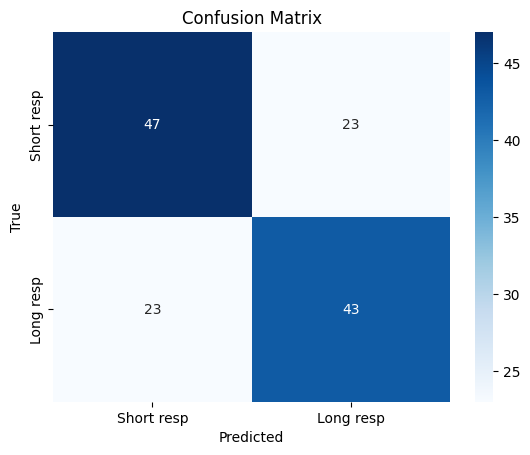

In [25]:
print('Concatenate Result Evaluation (5 folds):')
print(f'Train Macro f1: {np.mean(train_macro_f1s):.3f} +/- {np.std(train_macro_f1s):.3f}')
print(f'Train ROC-AUC:  {np.mean(train_roc_aucs):.3f} +/- {np.std(train_roc_aucs):.3f}')
print(f'Test Macro f1: {np.mean(test_macro_f1s):.3f} +/- {np.std(test_macro_f1s):.3f}')
print(f'Test ROC-AUC:  {np.mean(test_roc_aucs):.3f} +/- {np.std(test_roc_aucs):.3f}\n')

if BINARY_TARGET == True:
    target_names = ['Short resp', 'Long resp']
else:
    target_names = ['Short resp', 'Intermediate', 'Long resp']

print(classification_report(
    y_test_all, y_pred_test_all,
    target_names=target_names
))

cm = confusion_matrix(y_test_all, y_pred_test_all)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


## Explanation

In [26]:
shap_all = shap.Explanation(
    values        = np.concatenate([s.values for s in shap_values_list]),
    base_values   = np.concatenate([s.base_values for s in shap_values_list]),
    data          = np.concatenate([s.data for s in shap_values_list]),
    feature_names = shap_values_list[0].feature_names,
)
shap_all.values

array([[ 0.00000000e+00,  0.00000000e+00, -0.00000000e+00, ...,
         1.05456091e-02,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -0.00000000e+00,  0.00000000e+00, ...,
        -1.89595442e-02, -0.00000000e+00,  0.00000000e+00],
       [-0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -1.98376977e-02, -0.00000000e+00, -0.00000000e+00],
       ...,
       [ 3.92997062e-01,  1.43570450e-01,  4.97654718e-02, ...,
         6.04387451e-02, -2.41965225e-01, -5.42562332e-03],
       [-1.34462944e+00,  2.42333808e-01,  1.11072772e-01, ...,
         2.28453145e-02, -1.72734021e-01, -1.65176270e-04],
       [-4.62736227e-01, -5.61171820e-01,  4.64002871e-02, ...,
        -5.78586566e-03, -2.27844627e-01, -1.06814229e-02]],
      shape=(136, 10))

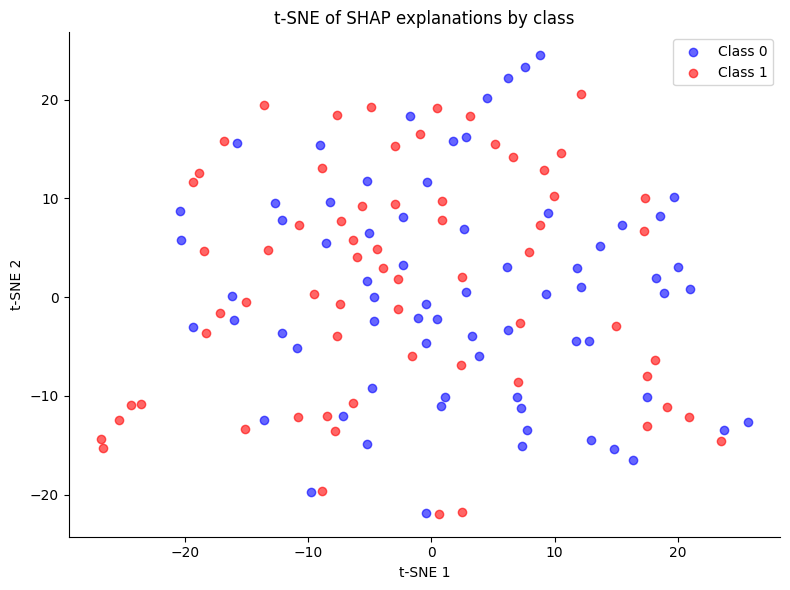

In [28]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap

def plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=None):
    colors = {0: "blue", 1: "red"}
    labels = {0: "Class 0", 1: "Class 1"}

    fig, ax = plt.subplots(figsize=(8, 6))

    for cls in [0, 1]:
        mask = y_arr == cls     # boolean
        ax.scatter(
            sv_2d[mask, 0], sv_2d[mask, 1],
            c=colors[cls], label=labels[cls],
            alpha=0.6,
        )

    if var is not None:
        ax.set_xlabel(f"PC1 ({var[0]:.1%} variance explained)")
        ax.set_ylabel(f"PC2 ({var[1]:.1%} variance explained)")
    else:
        ax.set_xlabel(f"{method_name} 1")
        ax.set_ylabel(f"{method_name} 2")

    ax.set_title(f"{method_name} of SHAP explanations by class")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
    
sv = shap_all.values
y_arr = np.array(y_test_all)  
    
# PCA — pass explained variance
# pca = PCA(n_components=2)
# sv_2d = pca.fit_transform(sv)
# plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=pca.explained_variance_ratio_)

# t-SNE
tsne = TSNE(n_components=2, perplexity=10, random_state=42)
sv_2d = tsne.fit_transform(sv)
plot_shap_reduction(sv_2d, y_arr, method_name="t-SNE")
 
# UMAP
# u_map = umap.UMAP(n_components=2, random_state=42)
# sv_2d = u_map.fit_transform(sv)
# plot_shap_reduction(sv_2d, y_arr, method_name="UMAP")

# # PaCMAP
# pac_map = pacmap.PaCMAP(n_components=2, random_state=42)
# sv_2d = pac_map.fit_transform(sv)
# plot_shap_reduction(sv_2d, y_arr, method_name="PaCMAP")


In [29]:
tsne

,"n_components n_components: int, default=2Dimension of the embedded space.",2
,"perplexity perplexity: float, default=30.0The perplexity is related to the number of nearest neighbors thatis used in other manifold learning algorithms. Larger datasetsusually require a larger perplexity. Consider selecting a valuebetween 5 and 50. Different values can result in significantlydifferent results. The perplexity must be less than the numberof samples.",10
,"early_exaggeration early_exaggeration: float, default=12.0Controls how tight natural clusters in the original space are inthe embedded space and how much space will be between them. Forlarger values, the space between natural clusters will be largerin the embedded space. Again, the choice of this parameter is notvery critical. If the cost function increases during initialoptimization, the early exaggeration factor or the learning ratemight be too high.",12.0
,"learning_rate learning_rate: float or ""auto"", default=""auto""The learning rate for t-SNE is usually in the range [10.0, 1000.0]. Ifthe learning rate is too high, the data may look like a 'ball' with anypoint approximately equidistant from its nearest neighbours. If thelearning rate is too low, most points may look compressed in a densecloud with few outliers. If the cost function gets stuck in a bad localminimum increasing the learning rate may help.Note that many other t-SNE implementations (bhtsne, FIt-SNE, openTSNE,etc.) use a definition of learning_rate that is 4 times smaller thanours. So our learning_rate=200 corresponds to learning_rate=800 inthose other implementations. The 'auto' option sets the learning_rateto `max(N / early_exaggeration / 4, 50)` where N is the sample size,following [4] and [5]... versionchanged:: 1.2 The default value changed to `""auto""`.",'auto'
,"max_iter max_iter: int, default=1000Maximum number of iterations for the optimization. Should be atleast 250... versionchanged:: 1.5 Parameter name changed from `n_iter` to `max_iter`.",1000
,"n_iter_without_progress n_iter_without_progress: int, default=300Maximum number of iterations without progress before we abort theoptimization, used after 250 initial iterations with earlyexaggeration. Note that progress is only checked every 50 iterations sothis value is rounded to the next multiple of 50... versionadded:: 0.17 parameter *n_iter_without_progress* to control stopping criteria.",300
,"min_grad_norm min_grad_norm: float, default=1e-7If the gradient norm is below this threshold, the optimization willbe stopped.",1e-07
,"metric metric: str or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string, it must be one of the optionsallowed by scipy.spatial.distance.pdist for its metric parameter, ora metric listed in pairwise.PAIRWISE_DISTANCE_FUNCTIONS.If metric is ""precomputed"", X is assumed to be a distance matrix.Alternatively, if metric is a callable function, it is called on eachpair of instances (rows) and the resulting value recorded. The callableshould take two arrays from X as input and return a value indicatingthe distance between them. The default is ""euclidean"" which isinterpreted as squared euclidean distance.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 1.1",None
,"init init: {""random"", ""pca""} or ndarray of shape (n_samples, n_components), default=""pca""Initialization of embedding.PCA initialization cannot be used with precomputed distances and isusually more globally stable than random initialization... versionchanged:: 1.2 The default value changed to `""pca""`.",'pca'
,"verbose verbose: int, default=0Verbosity level.",0


### Waterfall plot

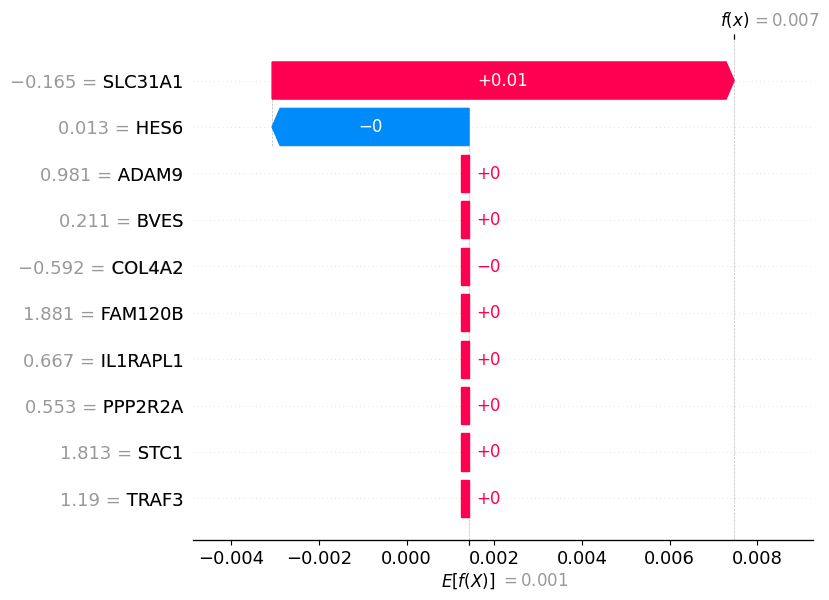

In [30]:
sample_idx = 0    
class_idx = 0

shap.plots.waterfall(shap_all[sample_idx])

### Force plot

In [31]:
shap.plots.force(shap_values[sample_idx, :, class_idx])

### Stacked force plot

In [32]:
shap.plots.force(shap_values[:, :, class_idx])


### Absolute mean SHAP

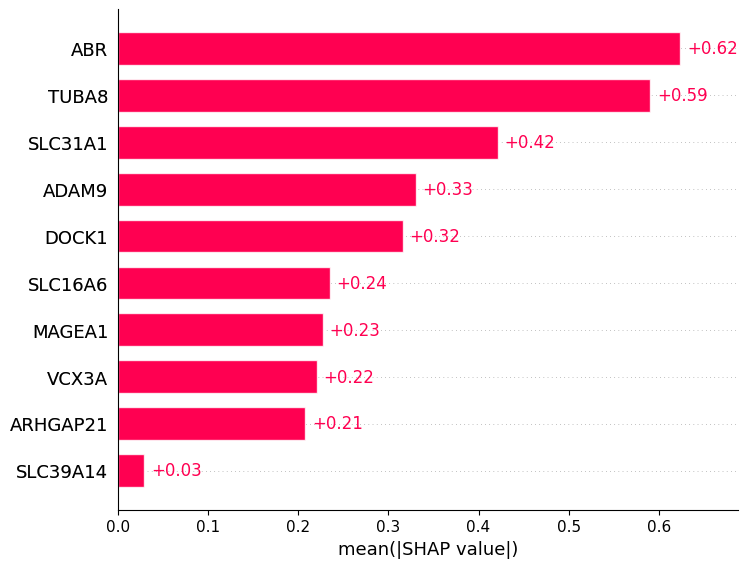

In [33]:
shap.plots.bar(shap_values[:, :, class_idx])

### Beeswarm plot

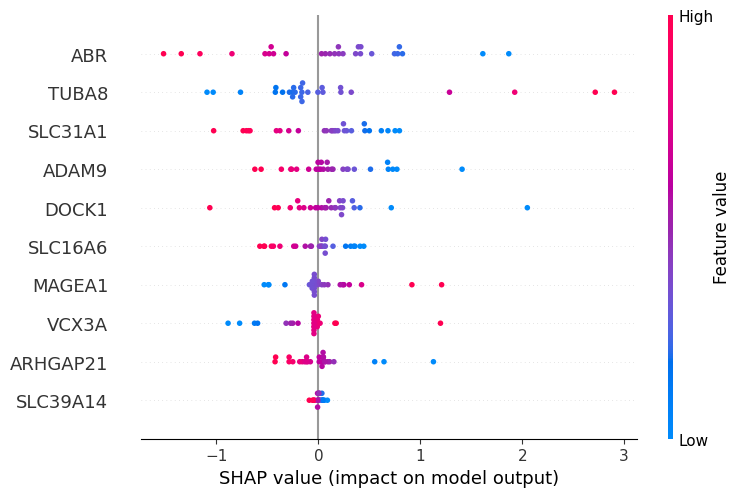

In [34]:
shap.plots.beeswarm(shap_values[:, :, class_idx])

### Dependence plots

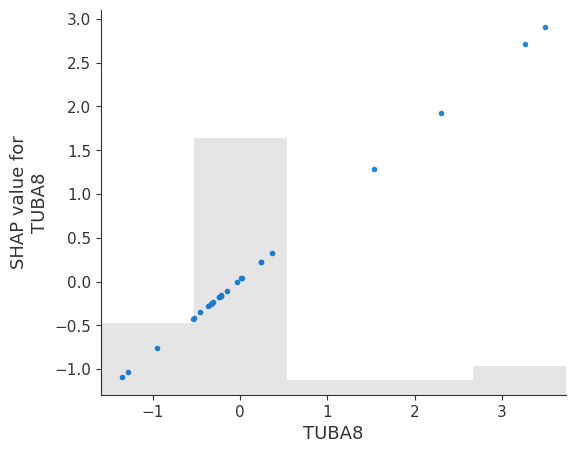

In [35]:
shap.plots.scatter(shap_values[:, 'TUBA8'])

In [36]:
shap.plots.scatter(
    shap_values=shap_values[:, 'TUBA8'],
    color=shap_values[:, 'ERICH1']
)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

### Heatmap plot

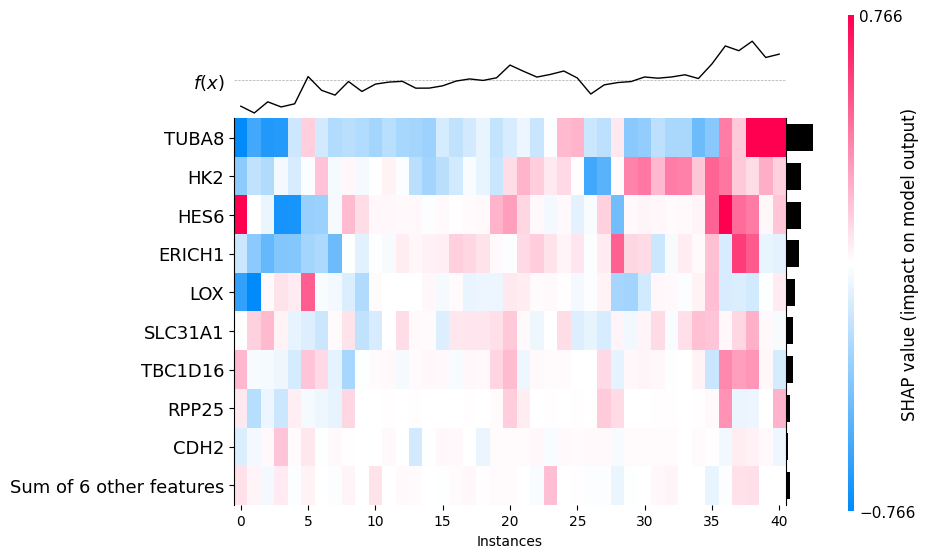

<Axes: xlabel='Instances'>

In [ ]:
shap.plots.heatmap(shap_values[:, :, class_idx])